# Task 1 Demo: MNIST Classification + OOP

This task implements three different classification models for the MNIST dataset:
1) Random Forest;
2) Feed-Forward Neural Network;
3) Convolutional Neural Network.

Each model implements a common abstract interface (MnistClassifierInterface) with two abstract methods — train and predict.
The models are accessed through a wrapper (MnistClassifier), which selects the algorithm based on the provided parameter.

## Used Machine Learning Libraries

No single framework covers both a classical ensemble model and deep neural
networks, so I used **scikit-learn** for the Random Forest and **PyTorch**
for the two neural networks.

- **Random Forest — scikit-learn**
  scikit-learn is the go-to library for classical ML in Python. It has a
  ready-made `RandomForestClassifier` [1] that trains an ensemble of
  decision trees on random subsets of the data and averages their votes to
  reduce overfitting [2]. I went with scikit-learn here simply because
  PyTorch doesn't have a built-in Random Forest, and writing one from
  scratch would be reinventing the wheel.

- **Feed-Forward NN and CNN — PyTorch**
  For the neural networks I preferred PyTorch over Keras because it makes the training loop
  explicit: you zero the gradients, do the forward pass, call
  `loss.backward()`, and step the optimizer yourself. With Keras you'd call
  `model.fit()` and the loop stays hidden, which is convenient but doesn't
  really show what's going on under the hood.

**References**:

1. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
2. https://scikit-learn.org/stable/modules/ensemble.html
3. https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html

## 1. Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import accuracy_score

from src.data_loader import load_mnist
from src.classifier import MnistClassifier
from src.utils import (
    plot_accuracy_comparison,
    plot_confusion_matrix,
    show_sample_predictions,
)
from config import NUM_EPOCHS, LEARNING_RATE, BATCH_SIZE

print("Imports OK")
print(
    f"Hyperparameters: epochs={NUM_EPOCHS}, lr={LEARNING_RATE}, batch_size={BATCH_SIZE}"
)

Imports OK
Hyperparameters: epochs=10, lr=0.001, batch_size=64


## 2. Load dataset

In [2]:
X_train, y_train, X_test, y_test = load_mnist()

# Need numpy copies for matplotlib and sklearn (they don't accept tensors)
X_train_np = X_train.numpy()
y_train_np = y_train.numpy()
X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"y_train : {y_train.shape}  dtype={y_train.dtype}")
print(f"X_test  : {X_test.shape}   dtype={X_test.dtype}")
print(f"Pixel range : [{X_train_np.min()}, {X_train_np.max()}]")

Train: (60000, 28, 28) | Test: (10000, 28, 28)
X_train : torch.Size([60000, 28, 28])  dtype=torch.uint8
y_train : torch.Size([60000])  dtype=torch.int64
X_test  : torch.Size([10000, 28, 28])   dtype=torch.uint8
Pixel range : [0, 255]


## 3. Exploratory Data Analysis

### 3.1 Sample images

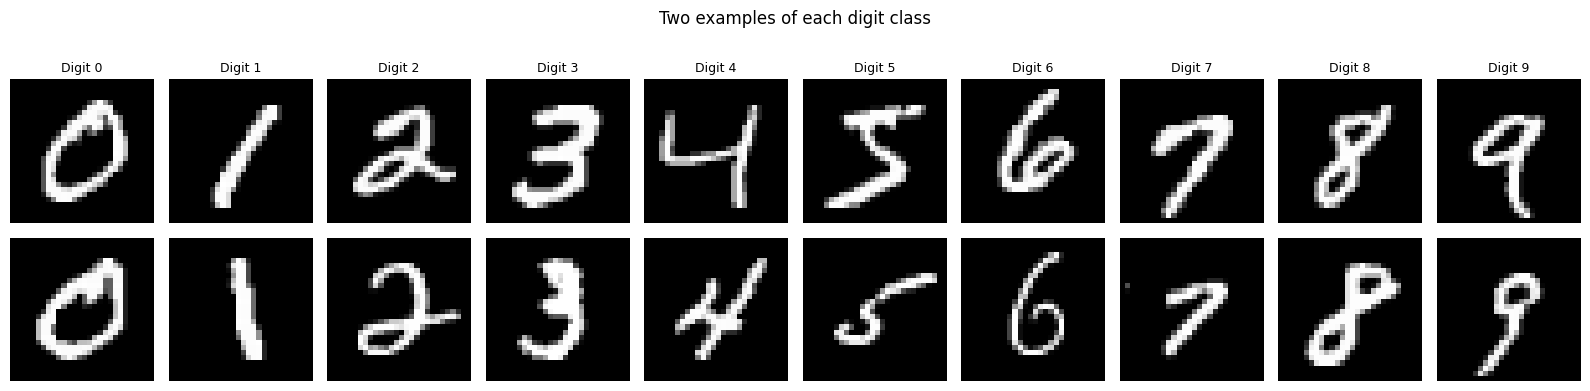

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    for row in range(2):
        idx = np.where(y_train_np == digit)[0][row]
        axes[row, digit].imshow(X_train_np[idx], cmap="gray")
        if row == 0:
            axes[row, digit].set_title(f"Digit {digit}", fontsize=9)
        axes[row, digit].axis("off")
plt.suptitle("Two examples of each digit class", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Class distribution: train vs test

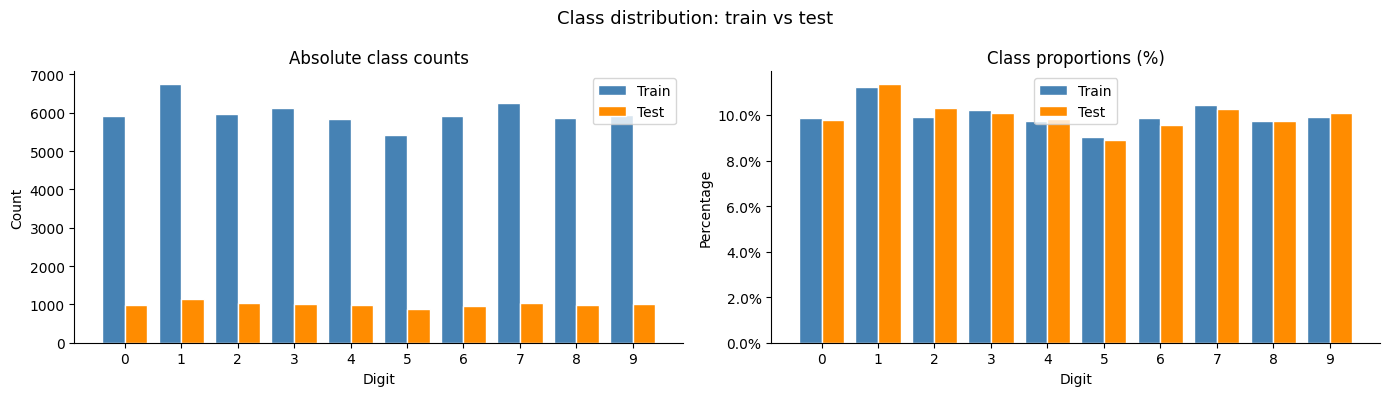

Train set : 60,000 images  |  Test set : 10,000 images
Train/test ratio : 6.0:1

Per-class counts (train):
  Digit 0: 5,923  (9.87%)
  Digit 1: 6,742  (11.24%)
  Digit 2: 5,958  (9.93%)
  Digit 3: 6,131  (10.22%)
  Digit 4: 5,842  (9.74%)
  Digit 5: 5,421  (9.04%)
  Digit 6: 5,918  (9.86%)
  Digit 7: 6,265  (10.44%)
  Digit 8: 5,851  (9.75%)
  Digit 9: 5,949  (9.92%)


In [4]:
# Checking if classes are balanced
train_counts = np.bincount(y_train_np, minlength=10)
test_counts = np.bincount(y_test_np, minlength=10)
digits = np.arange(10)
width = 0.4

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    digits - width / 2,
    train_counts,
    width=width,
    label="Train",
    color="steelblue",
    edgecolor="white",
)
axes[0].bar(
    digits + width / 2,
    test_counts,
    width=width,
    label="Test",
    color="darkorange",
    edgecolor="white",
)
axes[0].set_title("Absolute class counts")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Count")
axes[0].set_xticks(digits)
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Percentages make imbalance easier to spot
train_pct = train_counts / train_counts.sum() * 100
test_pct = test_counts / test_counts.sum() * 100
axes[1].bar(
    digits - width / 2,
    train_pct,
    width=width,
    label="Train",
    color="steelblue",
    edgecolor="white",
)
axes[1].bar(
    digits + width / 2,
    test_pct,
    width=width,
    label="Test",
    color="darkorange",
    edgecolor="white",
)
axes[1].set_title("Class proportions (%)")
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Percentage")
axes[1].set_xticks(digits)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Class distribution: train vs test", fontsize=13)
plt.tight_layout()
plt.show()

print(
    f"Train set : {len(X_train_np):,} images  |  Test set : {len(X_test_np):,} images"
)
print(f"Train/test ratio : {len(X_train_np) / len(X_test_np):.1f}:1")
print("\nPer-class counts (train):")
for d, c in enumerate(train_counts):
    print(f"  Digit {d}: {c:,}  ({c / train_counts.sum() * 100:.2f}%)")

### 3.3 Pixel intensity statistics

Global pixel statistics (training set):
  Min      : 0.0
  Max      : 255.0
  Mean     : 33.3184
  Std      : 78.5675
  Median   : 0.0
  Sparsity : 80.9% zero pixels


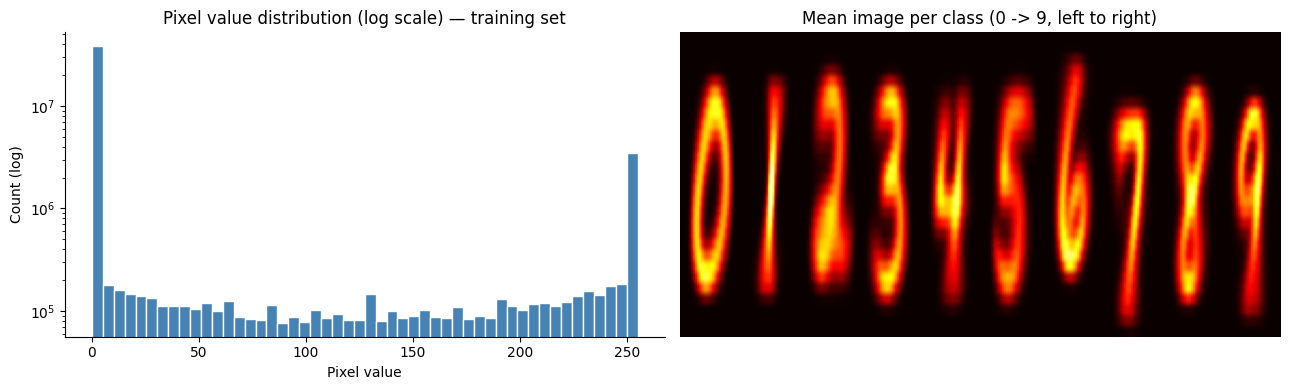

In [5]:
flat_train = X_train_np.reshape(-1).astype(np.float32)

print("Global pixel statistics (training set):")
print(f"  Min      : {flat_train.min():.1f}")
print(f"  Max      : {flat_train.max():.1f}")
print(f"  Mean     : {flat_train.mean():.4f}")
print(f"  Std      : {flat_train.std():.4f}")
print(f"  Median   : {np.median(flat_train):.1f}")
print(f"  Sparsity : {(flat_train == 0).mean() * 100:.1f}% zero pixels")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# log scale because the zero-pixel bin is massive
axes[0].hist(flat_train, bins=50, color="steelblue", edgecolor="white", log=True)
axes[0].set_title("Pixel value distribution (log scale) — training set")
axes[0].set_xlabel("Pixel value")
axes[0].set_ylabel("Count (log)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# average image per class — shows the "typical" shape of each digit
mean_images = np.array([X_train_np[y_train_np == d].mean(axis=0) for d in range(10)])
grid = np.concatenate(mean_images, axis=1)
axes[1].imshow(grid, cmap="hot", aspect="auto")
axes[1].set_title("Mean image per class (0 -> 9, left to right)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 3.3. Exploratory Data Analysis Summary
- **Balanced classes** — the bar chart (3.2) shows each digit makes up roughly 10% of the dataset, so no class reweighting is needed.
- **Standard split** — 60k train / 10k test (6:1), which is the default MNIST split.
- **Uniform image size** — all images are 28x28 greyscale, so no resizing or padding required.
- **Sparse pixels** — the histogram (3.3) confirms ~80% of pixels are zero (black background), which is expected for handwritten digits on a dark canvas.
- **Similar ink across classes** — the mean images show that some digits use more ink (like 0 with its loop) vs less (like 1), but the differences are small. The model will need to learn spatial patterns, not just pixel brightness.

## 4. Random Forest

In [6]:
# RF flattens 28x28 -> 784 features and builds 100 decision trees
rf_clf = MnistClassifier(algorithm="rf")
print(repr(rf_clf))
rf_clf.train(X_train, y_train)
rf_preds = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test_np, rf_preds)
print(f"Random Forest accuracy: {rf_acc:.4f}  ({rf_acc * 100:.2f}%)")

MnistClassifier(algorithm='rf')
[RF] Starting training...
[RF] Training complete — 100 trees
Random Forest accuracy: 0.9692  (96.92%)


## 5. Feed-Forward Neural Network

In [7]:
# Same API, different algorithm — two hidden layers (256 -> 128) with dropout
nn_clf = MnistClassifier(
    algorithm="nn", epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE
)
print(repr(nn_clf))
nn_clf.train(X_train, y_train)
nn_preds = nn_clf.predict(X_test)
nn_acc = accuracy_score(y_test_np, nn_preds)
print(f"Feed-Forward NN accuracy: {nn_acc:.4f}  ({nn_acc * 100:.2f}%)")

[NN] Device: cpu
MnistClassifier(algorithm='nn')
[NN] Epoch  1/10 — loss: 0.3242
[NN] Epoch  2/10 — loss: 0.1350
[NN] Epoch  3/10 — loss: 0.0980
[NN] Epoch  4/10 — loss: 0.0778
[NN] Epoch  5/10 — loss: 0.0678
[NN] Epoch  6/10 — loss: 0.0575
[NN] Epoch  7/10 — loss: 0.0500
[NN] Epoch  8/10 — loss: 0.0438
[NN] Epoch  9/10 — loss: 0.0426
[NN] Epoch 10/10 — loss: 0.0378
Feed-Forward NN accuracy: 0.9817  (98.17%)


## 6. Convolutional Neural Network

In [8]:
# Unlike the feed-forward network, the CNN preserves the 2D image structure.
# Convolutional layers slide small filters across the image to detect local
# patterns like edges and curves. That's why CNNs tend to outperform flat
# networks on image tasks.
cnn_clf = MnistClassifier(
    algorithm="cnn", epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE
)
print(repr(cnn_clf))
cnn_clf.train(X_train, y_train)
cnn_preds = cnn_clf.predict(X_test)
cnn_acc = accuracy_score(y_test_np, cnn_preds)
print(f"CNN accuracy: {cnn_acc:.4f}  ({cnn_acc * 100:.2f}%)")

[CNN] Device: cpu
MnistClassifier(algorithm='cnn')
[CNN] Epoch  1/10 — loss: 0.2141
[CNN] Epoch  2/10 — loss: 0.0706
[CNN] Epoch  3/10 — loss: 0.0499
[CNN] Epoch  4/10 — loss: 0.0402
[CNN] Epoch  5/10 — loss: 0.0340
[CNN] Epoch  6/10 — loss: 0.0276
[CNN] Epoch  7/10 — loss: 0.0235
[CNN] Epoch  8/10 — loss: 0.0210
[CNN] Epoch  9/10 — loss: 0.0181
[CNN] Epoch 10/10 — loss: 0.0158
CNN accuracy: 0.9915  (99.15%)


## 7. Compare results

Model accuracy summary:
  Random Forest     : 0.9692  (96.92%)
  Feed-Forward NN   : 0.9817  (98.17%)
  CNN               : 0.9915  (99.15%)


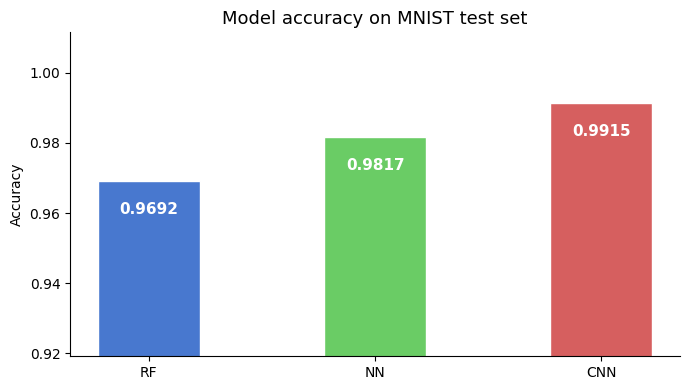

In [11]:
results = {"Random Forest": rf_acc, "Feed-Forward NN": nn_acc, "CNN": cnn_acc}
print("Model accuracy summary:")
for name, acc in results.items():
    print(f"  {name:<18}: {acc:.4f}  ({acc * 100:.2f}%)")
plot_accuracy_comparison({"RF": rf_acc, "NN": nn_acc, "CNN": cnn_acc})

## 8. Confusion matrices

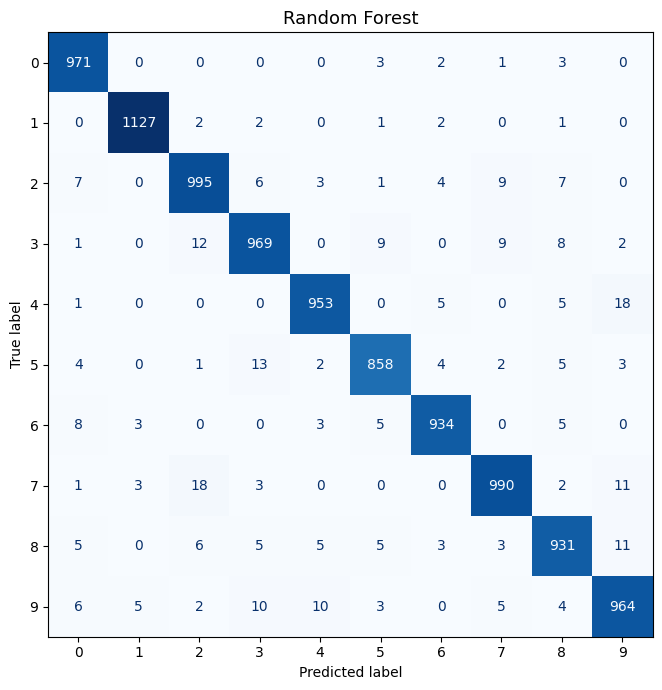

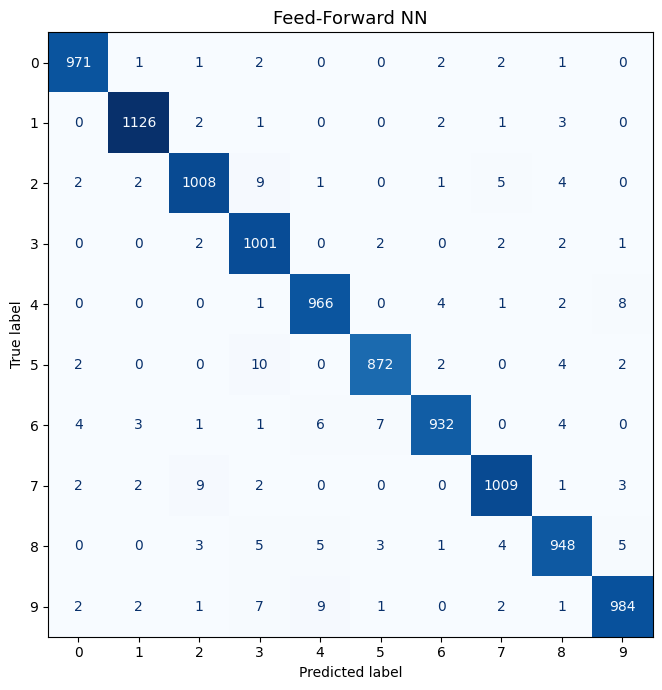

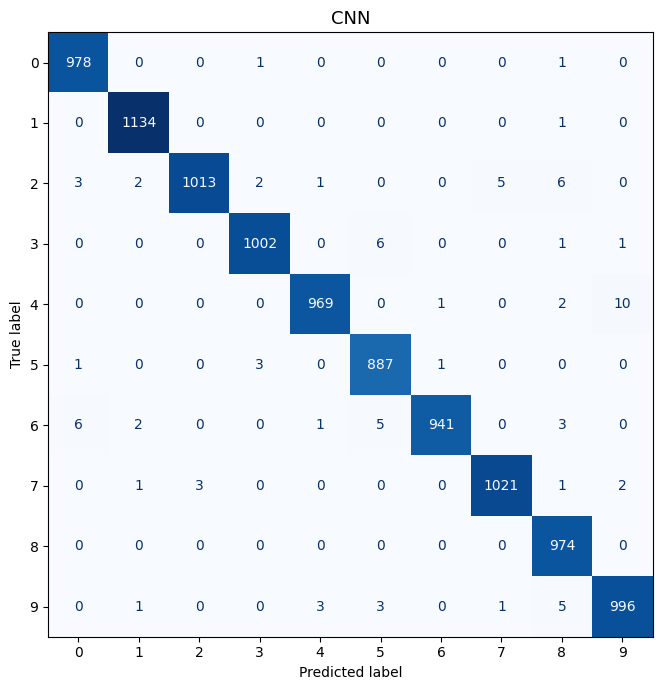

In [12]:
# Confusion matrices show which digits get mixed up (e.g. 4 vs 9, 3 vs 5)
plot_confusion_matrix(y_test_np, rf_preds, title="Random Forest")
plot_confusion_matrix(y_test_np, nn_preds, title="Feed-Forward NN")
plot_confusion_matrix(y_test_np, cnn_preds, title="CNN")

## 9. Sample predictions

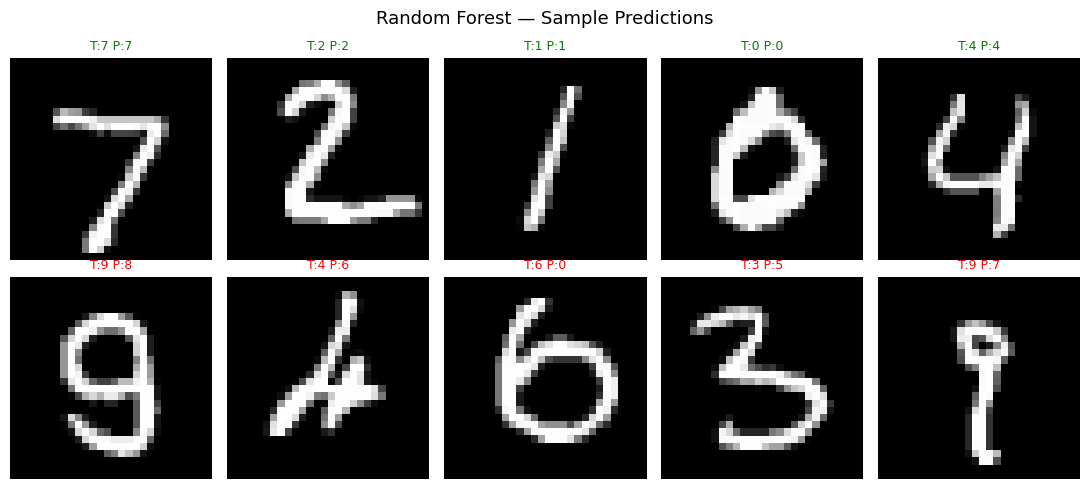

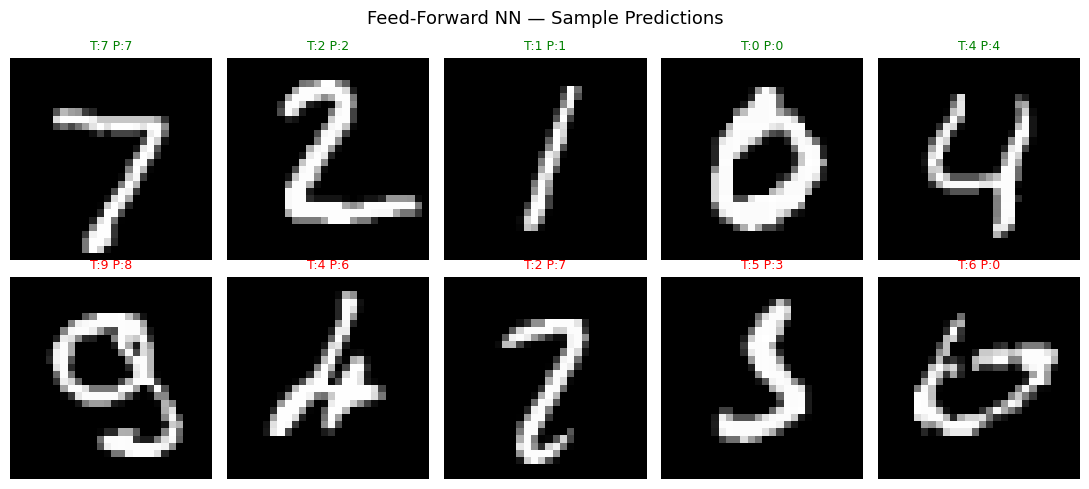

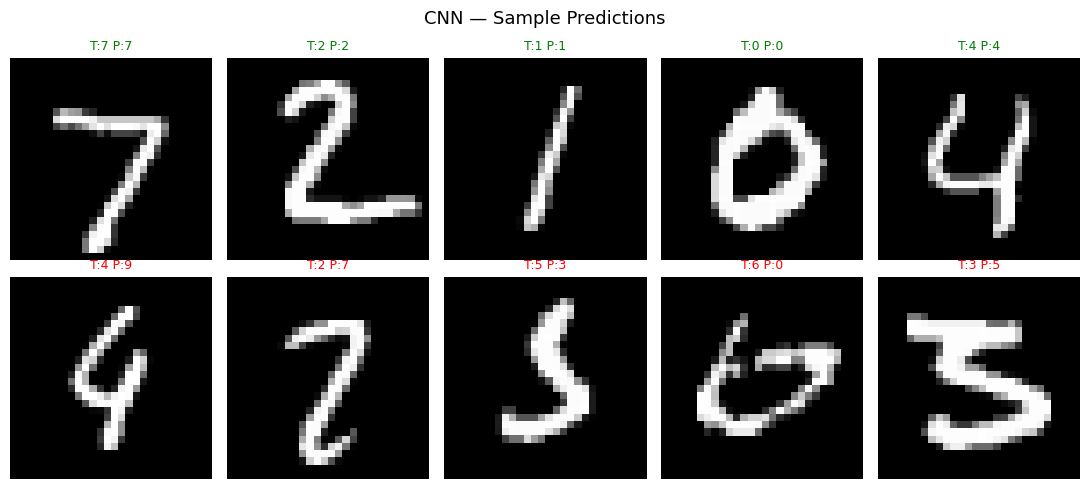

In [13]:
show_sample_predictions(X_test_np, y_test_np, rf_preds, model_name="Random Forest")
show_sample_predictions(X_test_np, y_test_np, nn_preds, model_name="Feed-Forward NN")
show_sample_predictions(X_test_np, y_test_np, cnn_preds, model_name="CNN")

## 10. Edge cases
Testing boundary conditions and error handling.

In [14]:
# Single image: all models should handle batch size of 1
print("Edge case 1: single image, shape (1, 28, 28)")
single = X_test[0:1]
true_label = y_test_np[0]
for name, clf in [("RF", rf_clf), ("NN", nn_clf), ("CNN", cnn_clf)]:
    pred = clf.predict(single)
    print(
        f"  {name}: shape={pred.shape}  predicted={pred[0]}  actual={true_label}  correct={pred[0] == true_label}"
    )

Edge case 1: single image, shape (1, 28, 28)
  RF: shape=(1,)  predicted=7  actual=7  correct=True
  NN: shape=(1,)  predicted=7  actual=7  correct=True
  CNN: shape=(1,)  predicted=7  actual=7  correct=True


In [15]:
# Should fail with a clear error, not silently break
print("Edge case 2: invalid algorithm name")
try:
    MnistClassifier(algorithm="svm")
except ValueError as e:
    print(f"  Caught ValueError: {e}")

Edge case 2: invalid algorithm name
  Caught ValueError: algorithm must be one of: 'rf', 'nn', 'cnn'.


In [16]:
# Calling predict before train should raise RuntimeError
print("Edge case 3: predict() before train()")
for algo in ["rf", "nn", "cnn"]:
    try:
        MnistClassifier(algorithm=algo).predict(X_test[:1])
    except RuntimeError as e:
        print(f"  {algo.upper()}: Caught RuntimeError: {e}")

Edge case 3: predict() before train()
  RF: Caught RuntimeError: Model has not been trained yet. Call train() before predict().
[NN] Device: cpu
  NN: Caught RuntimeError: Model has not been trained yet. Call train() before predict().
[CNN] Device: cpu
  CNN: Caught RuntimeError: Model has not been trained yet. Call train() before predict().


In [17]:
# Blank image: no right answer, but shouldn't crash
print("Edge case 4: blank image (all zeros)")
blank = torch.zeros(1, 28, 28, dtype=torch.uint8)
for name, clf in [("RF", rf_clf), ("NN", nn_clf), ("CNN", cnn_clf)]:
    pred = clf.predict(blank)
    print(f"  {name}: predicted={pred[0]}  (no ground truth — blank input)")

Edge case 4: blank image (all zeros)
  RF: predicted=7  (no ground truth — blank input)
  NN: predicted=5  (no ground truth — blank input)
  CNN: predicted=1  (no ground truth — blank input)


In [18]:
# Passing numpy instead of tensor: should get a clear TypeError
print("Edge case 6: wrong input type (numpy array instead of torch.Tensor)")
wrong_type = np.zeros((1, 28, 28), dtype=np.uint8)
for name, clf in [("RF", rf_clf), ("NN", nn_clf), ("CNN", cnn_clf)]:
    try:
        clf.predict(wrong_type)
    except TypeError as e:
        print(f"  {name}: Caught TypeError: {e}")

Edge case 6: wrong input type (numpy array instead of torch.Tensor)
  RF: Caught TypeError: X must be a torch.Tensor.
  NN: Caught TypeError: X must be a torch.Tensor.
  CNN: Caught TypeError: X must be a torch.Tensor.


In [19]:
# Wrong dimensions — model expects 28x28, not 32x32
print("Edge case 7: wrong image size (32x32 instead of 28x28)")
wrong_size = torch.zeros(1, 32, 32, dtype=torch.uint8)
for name, clf in [("RF", rf_clf), ("NN", nn_clf), ("CNN", cnn_clf)]:
    try:
        clf.predict(wrong_size)
    except ValueError as e:
        print(f"  {name}: Caught ValueError: {e}")

Edge case 7: wrong image size (32x32 instead of 28x28)
  RF: Caught ValueError: X must have shape (N, 28, 28).
  NN: Caught ValueError: X must have shape (N, 28, 28).
  CNN: Caught ValueError: X must have shape (N, 28, 28).


In [20]:
# Zero images in batch: should be caught by validation
print("Edge case 8: empty input tensor, shape (0, 28, 28)")
empty = torch.zeros(0, 28, 28, dtype=torch.uint8)
for name, clf in [("RF", rf_clf), ("NN", nn_clf), ("CNN", cnn_clf)]:
    try:
        clf.predict(empty)
    except ValueError as e:
        print(f"  {name}: Caught ValueError: {e}")

Edge case 8: empty input tensor, shape (0, 28, 28)
  RF: Caught ValueError: X cannot be empty.
  NN: Caught ValueError: X cannot be empty.
  CNN: Caught ValueError: X cannot be empty.


In [21]:
# Bad hyperparameters should be rejected before training starts
print("Edge case 9.1: invalid epoch count (epochs=0)")
try:
    MnistClassifier(algorithm="nn", epochs=0)
except ValueError as e:
    print(f"  Caught ValueError: {e}")

print("Edge case 9.2: learning rate out of range (lr=5.0, must be in (0, 1])")
try:
    MnistClassifier(algorithm="cnn", lr=5.0)
except ValueError as e:
    print(f"  Caught ValueError: {e}")

Edge case 9.1: invalid epoch count (epochs=0)
  Caught ValueError: epochs must be a positive integer.
Edge case 9.2: learning rate out of range (lr=5.0, must be in (0, 1])
  Caught ValueError: learning rate (lr) must be a number in the range (0, 1].


## 11. Conclusion
  The results came out as expected. Random Forest gets a strong baseline of 96.92%, the feed-forward NN improves on it with 98.13% by learning non-linear patterns, and the CNN does the best at 99.23% because it preserves the 2D structure of the image and can detect edges and shapes through its convolutional filters.
  Looking at the confusion matrices, all three models mostly mix up digits that genuinely look alike, like 4 vs 9, 3 vs 5, 7 vs 2. The CNN makes the fewest of these mistakes.
  The training logs show both neural networks converging steadily over 10 epochs (NN loss: 0.317 -> 0.037, CNN loss: 0.225 -> 0.017). The CNN starts lower and drops faster, which makes sense given it's a better architecture for image data.
  All edge cases pass. The validators catch bad input types, wrong shapes, empty tensors, and invalid hyperparameters, each with a clear error message telling exactly what went wrong.